In [14]:
from pathlib import Path
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from freezeplots.paths import APP_DIR
with open("channel_layout.json", "r", encoding="utf-8") as file:
    channel_layout = json.load(file)

# ============================================================
# File paths
# ============================================================

# The input file is CSV-formatted even though it has a .txt
# extension. Change the path if the file is elsewhere.
input_path = Path(os.path.join(APP_DIR['procdata'], 'manual_supercooling_events.csv'))

output_path = Path(
    "/home/juk/freeze/output/plots/"
    "SoilRPvsSF_WetaGrasCor-HeatMWCO.png"
)



Loaded 871 channel records from /home/juk/freeze/data/data_processed/manual_supercooling_events.csv
Plot saved to: /home/juk/freeze/output/plots/SoilRPvsSF_WetaGrasCor-HeatMWCO.png


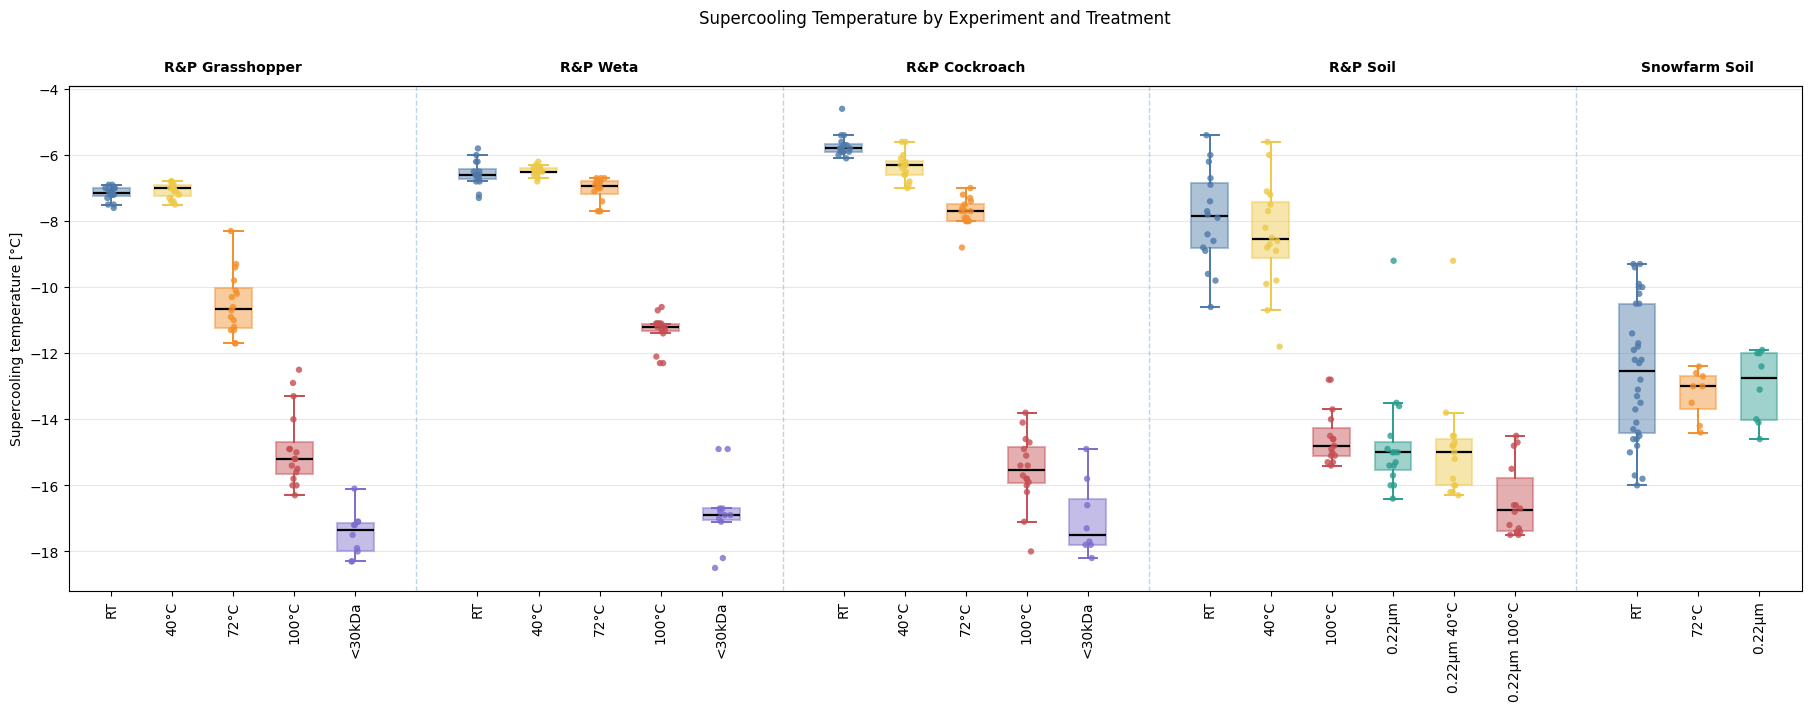

In [17]:

# ============================================================
# Read the cooling-event data
# ============================================================

if not input_path.is_file():
    raise FileNotFoundError(
        f"Input file was not found: {input_path.resolve()}"
    )

event_df = pd.read_csv(input_path)

required_columns = {
    "experiment_id",
    "channel",
    "start_temp_c",
}

missing_columns = required_columns.difference(event_df.columns)

if missing_columns:
    raise ValueError(
        "The input file is missing the following required "
        f"columns: {sorted(missing_columns)}"
    )


# Clean experiment and channel identifiers.
event_df["experiment_id"] = (
    event_df["experiment_id"]
    .astype("string")
    .str.strip()
)

event_df["channel"] = (
    event_df["channel"]
    .astype("string")
    .str.strip()
)


# Convert the temperature column to numeric. Empty cells and
# invalid values become NaN and will later be excluded.
event_df["start_temp_c"] = pd.to_numeric(
    event_df["start_temp_c"],
    errors="coerce",
)


# The existing plotting logic expects:
#
#     sc_df["supercooling_temp"]
#
# In the pasted file, the corresponding value is start_temp_c.
sc_df = event_df.rename(
    columns={
        "start_temp_c": "supercooling_temp",
    }
)

print(
    f"Loaded {len(sc_df)} channel records from "
    f"{input_path.resolve()}"
)


# ============================================================
# Treatment colors
# ============================================================

# Room temperature is blue.
# Increasing heat treatments progress from yellow to dark red.
# Filtration treatments use teal/violet colors.

TREATMENT_COLORS = {
    "RT": "#4C78A8",               # medium blue

    "40°C": "#EDC948",             # golden yellow
    "72°C": "#F28E2B",             # orange
    "100°C": "#C44E52",            # dark muted red

    "0.22µm": "#2A9D8F",           # teal
    "<30kDa": "#7B6DCC",           # medium violet

    "0.22µm 40°C": "#EDC948",      #  golden yellow
    "0.22µm 72°C": "#F28E2B",      # orange
    "0.22µm 100°C": "#C44E52",            # dark muted red

}


# ============================================================
# Plot-definition helpers
# ============================================================

def get_treatment_color(label, color=None):
    """
    Return an explicitly supplied color or look up the color
    associated with the treatment label.
    """
    if color is not None:
        return color

    if label is None:
        return "#808080"

    try:
        return TREATMENT_COLORS[label]

    except KeyError as error:
        raise ValueError(
            f"No color has been defined for treatment {label!r}. "
            "Add it to TREATMENT_COLORS or pass color explicitly."
        ) from error


def complete(experiment_id, label=None, color=None):
    """
    Define one boxplot containing all available channels from
    one experiment.
    """
    return {
        "label": label,
        "color": get_treatment_color(label, color),
        "sources": {
            experiment_id: None,
        },
    }


def combined(label, sources, color=None):
    """
    Define one boxplot by pooling selected channels from one or
    more experiments.
    """
    return {
        "label": label,
        "color": get_treatment_color(label, color),
        "sources": sources,
    }


# ============================================================
# Boxplot sections
# ============================================================

# The order of the sections determines the order of the major
# groups in the figure.
#
# The order of "plots" determines the boxplot order within each
# section.
#
# gap_after controls the horizontal space after each section.

plot_sections = [
    {
        "label": "R&P Grasshopper",
        "gap_after": 1.0,
        "plots": [
            complete("EJ19B1", "RT"),
            complete("EJ20B1", "40°C"),
            complete("EJ21B1", "72°C"),
            complete("EJ22B1", "100°C"),
            complete("EJ23B1", "<30kDa"),
        ],
    },

    {
        "label": "R&P Weta",
        "gap_after": 1.0,
        "plots": [
            complete("EJ24B1", "RT"),
            complete("EJ25B1", "40°C"),
            complete("EJ26B1", "72°C"),
            complete("EJ27B1", "100°C"),
            complete("EJ18B1", "<30kDa"),
        ],
    },

    {
        "label": "R&P Cockroach",
        "gap_after": 1.0,
        "plots": [
            complete("EJ29B1", "RT"),
            complete("EJ30B1", "40°C"),
            complete("EJ31B1", "72°C"),
            complete("EJ32B1", "100°C"),
            complete("EJ33B1", "<30kDa"),
        ],
    },

    {
        "label": "R&P Soil",
        "gap_after": 1.0,
        "plots": [
            complete("EJ09B1", "RT"),
            complete("EJ10B1", "40°C"),
            complete("EJ11B1", "100°C"),
            complete("EJ12B1", "0.22µm"),
            complete("EJ13B1", "0.22µm 40°C"),
            complete("EJ14B1", "0.22µm 100°C"),
        ],
    },

    {
        "label": "Snowfarm Soil",
        "gap_after": 1.0,
        "plots": [
            combined(
                "RT",
                {
                    "EJ01A1": [
                        "TC1", "TC2", "TC3", "TC4",
                        "TC5", "TC6", "TC7", "TC8",
                    ],
                    "EJ01A2": [
                        "TC1", "TC2", "TC3", "TC4",
                        "TC5", "TC6", "TC7", "TC8",
                    ],
                    "EJ01A3": [
                        "TC1", "TC2", "TC3", "TC4",
                        "TC5", "TC6", "TC7", "TC8",
                    ],
                    "EJ01A4": [
                        "TC1", "TC2", "TC3", "TC4",
                        "TC5", "TC6", "TC7", "TC8",
                    ],
                },
            ),

            combined(
                "72°C",
                {
                    "EJ02A1": [
                        "TC5", "TC6", "TC7", "TC8",
                    ],
                    "EJ02A2": [
                        "TC5", "TC6", "TC7", "TC8",
                    ],
                },
            ),

            combined(
                "0.22µm",
                {
                    "EJ02A1": [
                        "TC9", "TC10", "TC11", "TC12",
                    ],
                    "EJ02A2": [
                        "TC9", "TC10", "TC11", "TC12",
                    ],
                },
            ),
        ],
    },
]


# ============================================================
# Prepare experiment lookup
# ============================================================

# Group the DataFrame once so that it does not need to be scanned
# repeatedly for every boxplot definition.
experiment_data = {
    experiment_id: experiment_df
    for experiment_id, experiment_df in sc_df.groupby(
        "experiment_id",
        sort=False,
    )
}


# ============================================================
# Extract boxplot data
# ============================================================

experiments = []
temperatures = []
boxplot_colors = []
positions = []

section_ranges = []

current_position = 1.0


for section in plot_sections:
    section_label = section["label"]

    section_start = None
    section_end = None

    for plot_definition in section["plots"]:
        plot_label = plot_definition["label"]
        plot_color = plot_definition["color"]
        sources = plot_definition["sources"]

        combined_values = []

        for experiment_id, channels in sources.items():
            experiment_df = experiment_data.get(experiment_id)

            if experiment_df is None:
                print(
                    f"Warning: experiment {experiment_id!r} "
                    f"was not found in section {section_label!r}."
                )
                continue

            # None means that all available channels from the
            # experiment are included.
            if channels is None:
                selected_df = experiment_df

            else:
                # Also support one channel written as a string:
                #
                #     "TC1"
                #
                # instead of:
                #
                #     ["TC1"]
                if isinstance(channels, str):
                    channels = [channels]

                selected_df = experiment_df.loc[
                    experiment_df["channel"].isin(channels)
                ]

            values = (
                selected_df["supercooling_temp"]
                .dropna()
                .to_numpy()
            )

            if len(values) == 0:
                print(
                    f"Warning: no usable values found for "
                    f"{experiment_id!r}, channels {channels!r}, "
                    f"in section {section_label!r}."
                )
                continue

            combined_values.extend(values)

        if not combined_values:
            print(
                f"Warning: boxplot {plot_label!r} in section "
                f"{section_label!r} contains no usable values."
            )
            continue

        # A label should normally be supplied through complete()
        # or combined(). This fallback retains compatibility with
        # the earlier channel_layout labeling logic.
        if plot_label is None:
            if len(sources) != 1:
                raise ValueError(
                    "A boxplot containing multiple experiments "
                    "must have an explicit label."
                )

            experiment_id = next(iter(sources))

            if "channel_layout" not in globals():
                raise NameError(
                    "The boxplot has no explicit label and "
                    "channel_layout is not defined."
                )

            plot_label = channel_layout[
                experiment_id
            ]["TC1"]

        experiments.append(plot_label)
        temperatures.append(
            np.asarray(combined_values)
        )
        boxplot_colors.append(plot_color)
        positions.append(current_position)

        if section_start is None:
            section_start = current_position

        section_end = current_position
        current_position += 1.0

    if section_start is not None:
        section_ranges.append(
            {
                "label": section_label,
                "start": section_start,
                "end": section_end,
            }
        )

        current_position += section.get(
            "gap_after",
            1.0,
        )


if not temperatures:
    raise ValueError(
        "No supercooling-temperature values were found for "
        "the configured plot sections."
    )


# ============================================================
# Create plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(18, 7),
    constrained_layout=True,
)


boxplot_result = ax.boxplot(
    temperatures,
    positions=positions,
    widths=0.6,
    showfliers=False,
    patch_artist=True,
)


# ============================================================
# Style the boxplots
# ============================================================

for box, color in zip(
    boxplot_result["boxes"],
    boxplot_colors,
):
    box.set_facecolor(color)
    box.set_edgecolor(color)
    box.set_alpha(0.45)
    box.set_linewidth(1.5)


# Each box has two whiskers and two caps.
for index, color in enumerate(boxplot_colors):
    first_line = index * 2
    second_line = first_line + 1

    for line_index in (first_line, second_line):
        boxplot_result["whiskers"][
            line_index
        ].set_color(color)

        boxplot_result["whiskers"][
            line_index
        ].set_linewidth(1.4)

        boxplot_result["caps"][
            line_index
        ].set_color(color)

        boxplot_result["caps"][
            line_index
        ].set_linewidth(1.4)


for median in boxplot_result["medians"]:
    median.set_color("black")
    median.set_linewidth(1.6)


# ============================================================
# Add jittered data points
# ============================================================

rng = np.random.default_rng(seed=42)

for position, values, color in zip(
    positions,
    temperatures,
    boxplot_colors,
):
    x_jitter = rng.normal(
        loc=position,
        scale=0.05,
        size=len(values),
    )

    ax.scatter(
        x_jitter,
        values,
        s=21,
        color=color,
        edgecolors="none",
        alpha=0.8,
        zorder=3,
    )


# ============================================================
# Add x-axis labels
# ============================================================

ax.set_xticks(positions)

ax.set_xticklabels(
    experiments,
    rotation=90,
    ha="center",
)


# ============================================================
# Add section labels above the plot
# ============================================================

section_centers = [
    (section["start"] + section["end"]) / 2
    for section in section_ranges
]

section_labels = [
    section["label"]
    for section in section_ranges
]

section_axis = ax.secondary_xaxis("top")

section_axis.set_xticks(section_centers)

section_axis.set_xticklabels(
    section_labels,
    fontweight="bold",
)

section_axis.tick_params(
    axis="x",
    length=0,
    pad=8,
    labelsize=10,
)


# ============================================================
# Add separators between sections
# ============================================================

for left_section, right_section in zip(
    section_ranges[:-1],
    section_ranges[1:],
):
    separator_position = (
        left_section["end"]
        + right_section["start"]
    ) / 2

    ax.axvline(
        separator_position,
        linewidth=1,
        linestyle="--",
        alpha=0.3,
        zorder=0,
    )


# ============================================================
# Add treatment legend
# ============================================================

# Dictionary insertion order preserves the order in which the
# treatments first appear in the figure.
used_treatments = {}

for label, color in zip(
    experiments,
    boxplot_colors,
):
    used_treatments.setdefault(label, color)


legend_handles = [
    Patch(
        facecolor=color,
        edgecolor=color,
        alpha=0.6,
        label=label,
    )
    for label, color in used_treatments.items()
]

# ax.legend(
#     handles=legend_handles,
#     title="Treatment",
#     loc="upper left",
#     bbox_to_anchor=(1.01, 1.0),
#     frameon=False,
# )


# ============================================================
# Axis formatting
# ============================================================

ax.set_ylabel("Supercooling temperature [°C]")

ax.set_title(
    "Supercooling Temperature by Experiment and Treatment",
    pad=45,
)

ax.grid(
    axis="y",
    alpha=0.3,
)

ax.set_xlim(
    min(positions) - 0.7,
    max(positions) + 0.7,
)


# ============================================================
# Save and display
# ============================================================

output_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

print(
    f"Plot saved to: {output_path.resolve()}"
)

plt.show()